Apps Data:
   Unnamed: 0                                                App  \
0           0     Photo Editor & Candy Camera & Grid & ScrapBook   
1           1                                Coloring book moana   
2           2  U Launcher Lite – FREE Live Cool Themes, Hide ...   
3           3                              Sketch - Draw & Paint   
4           4              Pixel Draw - Number Art Coloring Book   

         Category  Rating  Reviews  Size     Installs  Type Price  \
0  ART_AND_DESIGN     4.1      159  19.0      10,000+  Free     0   
1  ART_AND_DESIGN     3.9      967  14.0     500,000+  Free     0   
2  ART_AND_DESIGN     4.7    87510   8.7   5,000,000+  Free     0   
3  ART_AND_DESIGN     4.5   215644  25.0  50,000,000+  Free     0   
4  ART_AND_DESIGN     4.3      967   2.8     100,000+  Free     0   

  Content Rating                     Genres      Last Updated  \
0       Everyone               Art & Design   January 7, 2018   
1       Everyone  Art & Design;Pret

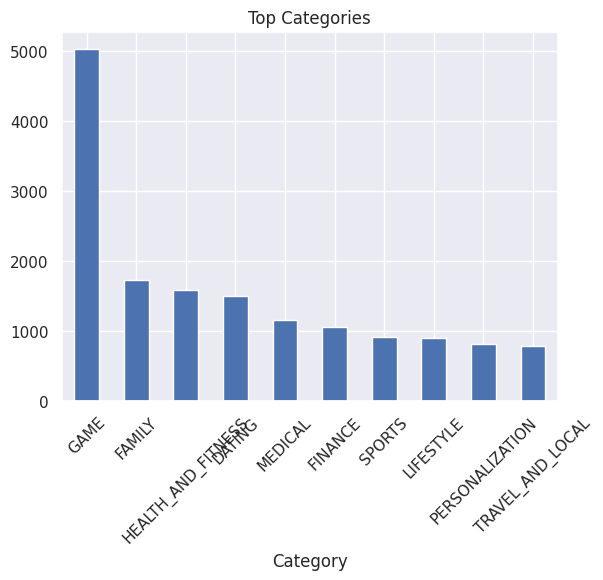

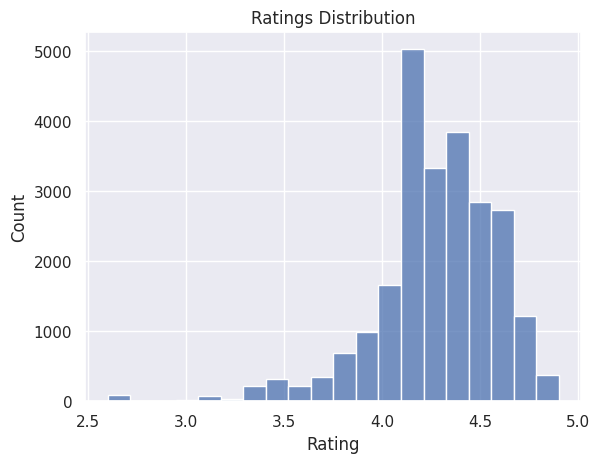

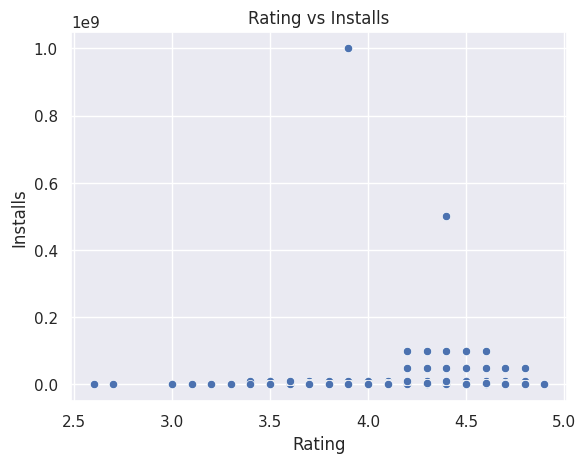

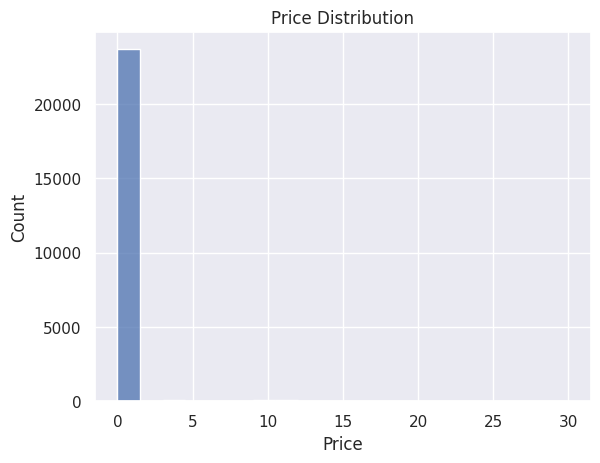

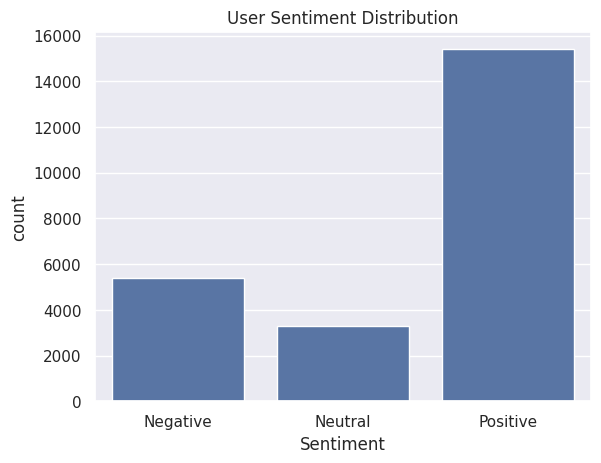


Sentiment Count:
Sentiment
Positive    15401
Negative     5392
Neutral      3276
Name: count, dtype: int64


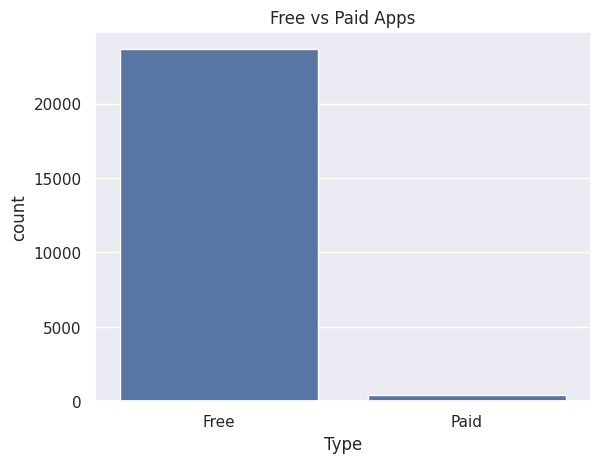

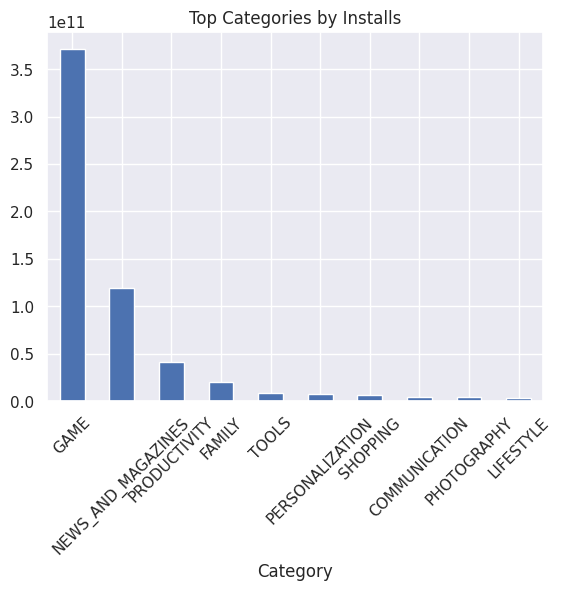

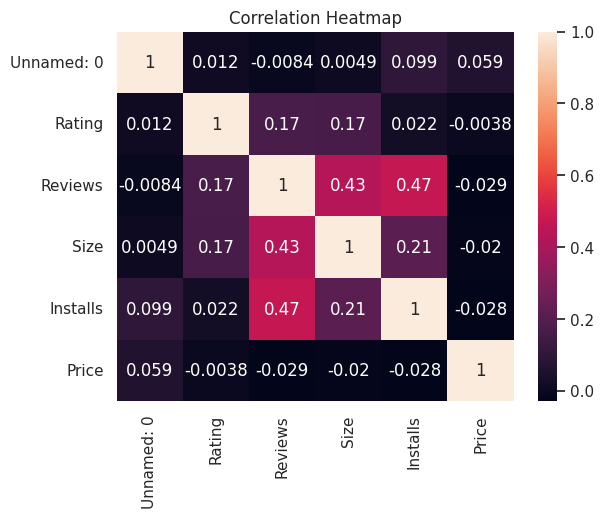


--- Key Insights ---
1. Few categories dominate the Play Store.
2. Free apps are more than paid apps.
3. Ratings do not always mean more installs.
4. Most user sentiments are positive.
5. Some apps receive higher engagement.

 Project Completed Successfully!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

apps = pd.read_csv("apps.csv")
reviews = pd.read_csv("user_reviews.csv")

print("Apps Data:")
print(apps.head())

print("\nReviews Data:")
print(reviews.head())

apps.dropna(inplace=True)

apps['Size'] = apps['Size'].astype(str)
apps['Size'] = apps['Size'].str.replace('M', '', regex=False)
apps['Size'] = apps['Size'].str.replace('k', '', regex=False)
apps['Size'] = apps['Size'].replace('Varies with device', '0')
apps['Size'] = apps['Size'].astype(float)

apps['Installs'] = apps['Installs'].str.replace('+', '', regex=False)
apps['Installs'] = apps['Installs'].str.replace(',', '', regex=False)
apps['Installs'] = apps['Installs'].astype(int)

apps['Price'] = apps['Price'].str.replace('$', '', regex=False)
apps['Price'] = apps['Price'].astype(float)

apps['Reviews'] = apps['Reviews'].astype(int)

reviews.dropna(inplace=True)

reviews = reviews[['App', 'Sentiment']]

data = pd.merge(apps, reviews, on='App', how='inner')

print("\nMerged Data:")
print(data.head())

plt.figure()
data['Category'].value_counts().head(10).plot(kind='bar')
plt.title("Top Categories")
plt.xticks(rotation=45)
plt.show()

plt.figure()
sns.histplot(data['Rating'], bins=20)
plt.title("Ratings Distribution")
plt.show()

plt.figure()
sns.scatterplot(x='Rating', y='Installs', data=data)
plt.title("Rating vs Installs")
plt.show()

plt.figure()
sns.histplot(data['Price'], bins=20)
plt.title("Price Distribution")
plt.show()

plt.figure()
sns.countplot(x='Sentiment', data=data)
plt.title("User Sentiment Distribution")
plt.show()

print("\nSentiment Count:")
print(data['Sentiment'].value_counts())

plt.figure()
sns.countplot(x='Type', data=data)
plt.title("Free vs Paid Apps")
plt.show()

plt.figure()
data.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Categories by Installs")
plt.xticks(rotation=45)
plt.show()

plt.figure()
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

print("\n--- Key Insights ---")
print("1. Few categories dominate the Play Store.")
print("2. Free apps are more than paid apps.")
print("3. Ratings do not always mean more installs.")
print("4. Most user sentiments are positive.")
print("5. Some apps receive higher engagement.")

data.to_csv("cleaned_playstore_with_reviews.csv", index=False)

print("\n Project Completed Successfully!")